# ML—Applied Deep Learning with TensorFlow

This notebook follows the course PDF.  
I include Markdown note blocks between code blocks as required.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print ("TF version:", tf.__version__)


## 1) Tensors + basic TensorFlow stuff 

Goal: understand tensors (numbers, vectors, matrices), shapes, dtypes.
The teacher said most errors are shape/dtype problems, so I am focusing on that.

In [6]:
# 1) Scalars, vectors, matrices, tensors
scalar = tf.constant(7)  # rank 0
vector = tf.constant([10, 20, 30])  # rank 1
matrix = tf.constant([[1., 2.], [3., 4.]])  # rank 2
tensor = tf.constant([[[1],[2]], [[3],[4]]])  # rank 3 (2x2x1)

print("scalar:", scalar, "shape:", scalar.shape)
print("vector shape:", vector.shape)
print("matrix shape:", matrix.shape)
print("tensor shape:", tensor.shape)

scalar: tf.Tensor(7, shape=(), dtype=int32) shape: ()
vector shape: (3,)
matrix shape: (2, 2)
tensor shape: (2, 2, 1)


### Notes (shape / rank)

- scalar = just one number, shape `()`
- vector = list, shape like `(3,)`
- matrix = table, shape like `(rows, cols)`
- higher tensor = more dims (example `(2,2,1)`)

Note to self: in ML, model only sees numbers. The meaning comes from the shape.
If shape is wrong, TensorFlow can’t “guess” what I meant.

In [7]:
# 2) Dtypes and casting
x = tf.constant([1.7, 7.4])  # float32 usually
y = tf.constant([7, 10])     # int32 usually

print("x dtype:", x.dtype)
print("y dtype:", y.dtype)

x16 = tf.cast(x, tf.float16)   # lower precision float
y32 = tf.cast(y, tf.float32)   # int -> float

print("x16 dtype:", x16.dtype)
print("y32 dtype:", y32.dtype)

x dtype: <dtype: 'float32'>
y dtype: <dtype: 'int32'>
x16 dtype: <dtype: 'float16'>
y32 dtype: <dtype: 'float32'>


### Notes (dtype)

- dtype = data type (float32, int32, etc.)
- usually NN training uses float32
- casting is useful if I mix ints + floats or need a specific type

In [8]:
# 3) Indexing and shaping
rank2 = tf.constant([[10, 7],
                     [3, 4]])

last_col = rank2[:, -1]             # take last column
expanded = tf.expand_dims(rank2, -1) # add a new axis at end
squeezed = tf.squeeze(expanded, axis=-1)

print("rank2:\n", rank2.numpy())
print("last_col:", last_col.numpy(), "shape:", last_col.shape)
print("expanded shape:", expanded.shape)
print("squeezed shape:", squeezed.shape)

rank2:
 [[10  7]
 [ 3  4]]
last_col: [7 4] shape: (2,)
expanded shape: (2, 2, 1)
squeezed shape: (2, 2)


### Notes (expand_dims / squeeze)

- `expand_dims` adds a dimension of size 1
  Example: (2,2) -> (2,2,1)
- `squeeze` removes dimensions of size 1

This is common for images because CNN usually expects (H, W, C).

In [9]:
# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.],
                 [3., 4.]])

print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

A+10:
 tf.Tensor(
[[20. 17.]
 [13. 14.]], shape=(2, 2), dtype=float32)
A*2:
 tf.Tensor(
[[20. 14.]
 [ 6.  8.]], shape=(2, 2), dtype=float32)


# 4) Broadcasting & basic ops
A = tf.constant([[10., 7.],
                 [3., 4.]])

print("A+10:\n", A + 10)
print("A*2:\n", A * 2)

In [10]:
# 5) Matrix multiplication rules (inner dims must match)
X = tf.constant([[1, 2],
                 [3, 4],
                 [5, 6]], dtype=tf.float32)  # (3x2)

Y = tf.constant([[7, 8],
                 [9, 10],
                 [11, 12]], dtype=tf.float32)  # (3x2)

XtY = tf.matmul(X, tf.transpose(Y))  # (3x2) @ (2x3) -> (3x3)
print("XtY shape:", XtY.shape)
print(XtY.numpy())

XtY shape: (3, 3)
[[ 23.  29.  35.]
 [ 53.  67.  81.]
 [ 83. 105. 127.]]


### Notes (matmul)

Rule: if A is (m,n) then B must be (n,p).
Output will be (m,p).

In neural networks, Dense layers are basically:
`output = XW + b`
So matrix multiply is everywhere.

In [11]:
# 6) Aggregations
E = tf.constant(np.random.randint(0, 100, size=10))
print("E:", E.numpy())
print("min:", tf.reduce_min(E).numpy(),
      "max:", tf.reduce_max(E).numpy(),
      "mean:", tf.reduce_mean(tf.cast(E, tf.float32)).numpy(),
      "sum:", tf.reduce_sum(E).numpy())

# 7) One-hot encoding
idx = tf.constant([0, 1, 2, 3])
oh = tf.one_hot(idx, depth=4)
print("one-hot:\n", oh.numpy())

# 8) NumPy interop
arr = np.array([3., 7., 10.])
t = tf.constant(arr)
back_to_np = t.numpy()
print("back_to_np:", back_to_np)
print("OK")

E: [66 99 53 78 87 88  0 41 65 66]
min: 0 max: 99 mean: 64.3 sum: 643
one-hot:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
back_to_np: [ 3.  7. 10.]
OK


### Final notes (for this part)

Main takeaway: most problems are shape + dtype issues.
So I should always check:
- `.shape`
- rank (how many dims)
- dtype (float32/int32)

## 2) Regression (predicting a continuous value)

Regression = predict a number (not a class).
Example from PDF: learn the pattern `y = x + 10`.

Important things:
- output is 1 number
- last layer usually `Dense(1)` (no softmax/sigmoid)
- loss can be MAE or MSE
- we should test on data the model didn’t train on (generalization)

In [12]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# simple linear data (same as PDF)
X = np.arange(-20, 21, 2, dtype=np.float32)   # [-20, -18, ..., 20]
y = X + 10

# train/test split (simple)
X_train, y_train = X[:20], y[:20]
X_test, y_test = X[20:], y[20:]

print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)
print("First 5 train:", list(zip(X_train[:5], y_train[:5])))

X_train shape: (20,) y_train shape: (20,)
X_test shape: (1,) y_test shape: (1,)
First 5 train: [(np.float32(-20.0), np.float32(-10.0)), (np.float32(-18.0), np.float32(-8.0)), (np.float32(-16.0), np.float32(-6.0)), (np.float32(-14.0), np.float32(-4.0)), (np.float32(-12.0), np.float32(-2.0))]


### Notes (train vs test)

If I train + test on the same data, it can look “perfect” but it might just memorize.
So we keep some data as test data to see if it works on new inputs.
That’s what “generalization” means.

In [13]:
# 1) CREATE model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1,)),
    tf.keras.layers.Dense(1)   # 1 output neuron for regression
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

### Notes (model)

This is basically the simplest neural net:
- input: 1 number (x)
- output: 1 number (y)

Dense(1) means it learns something like: y ≈ w*x + b

In [14]:
# 2) COMPILE model
model.compile(
    loss="mae",  # mean absolute error
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    metrics=["mae"]
)

### Notes (compile)

- loss = how wrong the predictions are (we want it small)
- optimizer = how weights get updated (SGD is simple)
- learning rate = step size (too big = unstable, too small = slow)
- epochs = how many times it goes through the training data

In [15]:
# 3) FIT model (train)
history = model.fit(X_train, y_train, epochs=200, verbose=0)

# show last few training errors
print("Last 5 MAE values:", history.history["mae"][-5:])

Last 5 MAE values: [7.7397141456604, 7.738691806793213, 7.720714569091797, 7.721590995788574, 7.7034912109375]


### Notes (overfitting idea)

Training error usually keeps going down with more epochs.
But test performance can stop improving or even get worse if the model starts fitting noise.

So best model = not the one with the smallest training error,
but the one that works best on test/unknown data.

In [16]:
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print("Test MAE:", mae)

Test MAE: 16.02477264404297


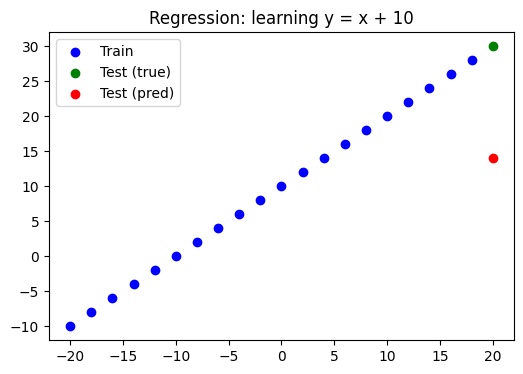

X_test: [20.]
y_test: [30.]
y_pred: 13.975226


In [17]:
y_pred = model.predict(X_test, verbose=0).squeeze()

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, c="b", label="Train")
plt.scatter(X_test, y_test, c="g", label="Test (true)")
plt.scatter(X_test, y_pred, c="r", label="Test (pred)")
plt.legend()
plt.title("Regression: learning y = x + 10")
plt.show()

print("X_test:", X_test)
print("y_test:", y_test)
print("y_pred:", y_pred)

### Quick summary (regression)

Workflow is always:
1) Create model
2) Compile (loss + optimizer + metric)
3) Fit (train)
Then evaluate + plot to see if it learned the real pattern.

## 3A) Binary classification (circles dataset)

Binary classification = 2 classes (0 or 1).
Model output is a probability between 0 and 1.

Important:
- last layer: Dense(1, activation="sigmoid")
- loss: binary_crossentropy
- metric: accuracy

PDF point: circles data is NOT linearly separable, so we need non-linearity (ReLU).

X shape: (1000, 2) y shape: (1000,)
Train: (800, 2) Test: (200, 2)


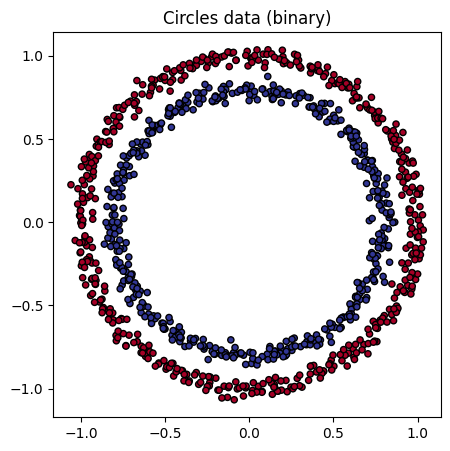

In [18]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split

# dataset (same idea as PDF)
X, y = make_circles(n_samples=1000, noise=0.03, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X shape:", X.shape, "y shape:", y.shape)
print("Train:", X_train.shape, "Test:", X_test.shape)

# quick view
plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap=plt.cm.RdYlBu, edgecolor="k", s=20)
plt.title("Circles data (binary)")
plt.show()

### Notes (why linear model fails here)

A straight line can’t separate “inside circle” vs “outside circle”.
So if the model is only linear, it will struggle.

ReLU activation makes it non-linear, so it can learn curved boundaries.

In [20]:
# 1) CREATE (non-linear hidden layers + sigmoid output)
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(2,)),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

# 2) COMPILE
model.compile(
    loss="binary_crossentropy",
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=["accuracy"]
)

# 3) FIT
history = model.fit(X_train, y_train, epochs=25, verbose=0)

# EVALUATE
loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {acc:.3f}")

Test accuracy: 0.995


### Notes (probabilities)

Sigmoid output is a probability (like 0.93), not a class label.
To get class:
- if prob > 0.5 -> class 1
- else -> class 0

Threshold can be changed, but 0.5 is default.

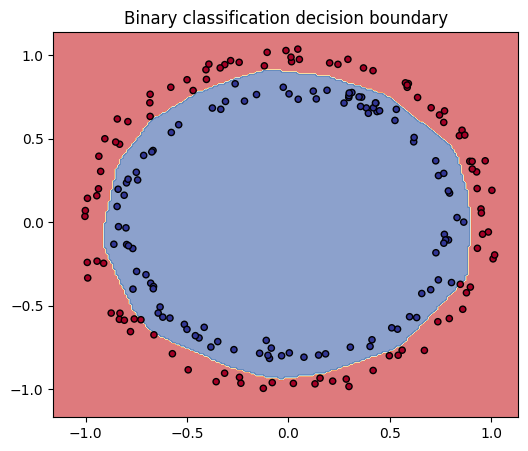

In [21]:
# visualize decision boundary
xx, yy = np.meshgrid(
    np.linspace(X[:,0].min()-0.1, X[:,0].max()+0.1, 200),
    np.linspace(X[:,1].min()-0.1, X[:,1].max()+0.1, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
probs = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(6,5))
plt.contourf(xx, yy, (probs > 0.5).astype(int), cmap=plt.cm.RdYlBu, alpha=0.6)
plt.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap=plt.cm.RdYlBu, edgecolor="k", s=20)
plt.title("Binary classification decision boundary")
plt.show()

### Quick summary (binary)

Binary classification setup:
- Dense(1, sigmoid)
- loss = binary_crossentropy
- metric = accuracy

Need ReLU layers to solve non-linear patterns like circles.

## 3B) Multiclass classification (Fashion-MNIST)

Multiclass = more than 2 classes (here 10 classes).
Model outputs 10 probabilities (they sum to 1).

Important:
- last layer: Dense(10, activation="softmax")
- loss: sparse_categorical_crossentropy (because labels are integers 0..9)
- normalize images to [0,1] by dividing by 255

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train: (60000, 28, 28) y_train: (60000,)
x_test: (10000, 28, 28) y_test: (10000,)


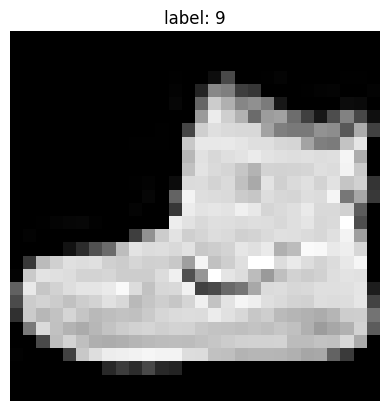

In [22]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

# normalize (PDF says this helps)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# show one image
plt.imshow(x_train[0], cmap="gray")
plt.title(f"label: {y_train[0]}")
plt.axis("off")
plt.show()

### Notes (normalization)

Original pixel values are 0..255.
We scale to 0..1 by /255.

This usually makes training faster + more stable.

In [23]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    validation_split=0.1,
    verbose=0
)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy:", acc)

Test accuracy: 0.8806999921798706


### Notes (loss choice)

My labels are integers (0..9), not one-hot vectors.
So we use: sparse_categorical_crossentropy.

If labels were one-hot like [0,0,1,0,...], then we use categorical_crossentropy.

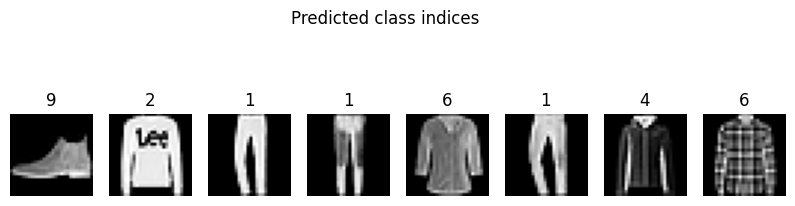

true labels:  [9 2 1 1 6 1 4 6]
pred labels:  [9 2 1 1 6 1 4 6]


In [24]:
probs = model.predict(x_test[:8], verbose=0)   # shape (8,10)
preds = probs.argmax(axis=1)

plt.figure(figsize=(10,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(int(preds[i]))
    plt.axis("off")
plt.suptitle("Predicted class indices")
plt.show()

print("true labels: ", y_test[:8])
print("pred labels: ", preds)

### Quick summary (multiclass)

Multiclass setup:
- Dense(K, softmax) where K = number of classes
- loss = sparse_categorical_crossentropy (if labels are integer IDs)
- normalize images (0..1) to help learning

## 4) CNN (Convolutional Neural Network) for images

Dense network + Flatten treats image like just a long list of numbers.
But images have structure (edges, shapes, position).

CNN idea:
- Conv2D learns small patterns (like edges) using filters
- MaxPool reduces image size and keeps strongest features (more robust)

Also CNN expects image shape like (H, W, C).
Fashion-MNIST is (28,28) so we add channel -> (28,28,1).

In [25]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# keep only classes 7 and 9 (PDF example: Sneaker vs Ankle boot)
train_mask = np.isin(y_train, [7, 9])
test_mask = np.isin(y_test, [7, 9])

x_train_bin = x_train[train_mask]
y_train_bin = y_train[train_mask]
x_test_bin = x_test[test_mask]
y_test_bin = y_test[test_mask]

# add channel dim + normalize
x_train_bin = x_train_bin[..., None].astype("float32") / 255.0   # (N,28,28,1)
x_test_bin  = x_test_bin[..., None].astype("float32") / 255.0

# make labels binary: 1 if class 9 else 0
y_train_bin = (y_train_bin == 9).astype(np.float32)
y_test_bin  = (y_test_bin == 9).astype(np.float32)

print("x_train_bin:", x_train_bin.shape, "y_train_bin:", y_train_bin.shape)
print("x_test_bin:", x_test_bin.shape, "y_test_bin:", y_test_bin.shape)
print("label meaning: 0 -> class 7 (sneaker), 1 -> class 9 (ankle boot)")

x_train_bin: (12000, 28, 28, 1) y_train_bin: (12000,)
x_test_bin: (2000, 28, 28, 1) y_test_bin: (2000,)
label meaning: 0 -> class 7 (sneaker), 1 -> class 9 (ankle boot)


### Notes (shapes)

Before: images were (28,28)
Now: (28,28,1) because CNN expects channel dimension.

If I forget [..., None], Conv2D input shape won’t match.

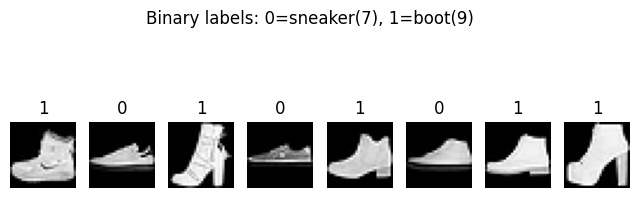

In [26]:
plt.figure(figsize=(8,3))
for i in range(8):
    plt.subplot(1,8,i+1)
    plt.imshow(x_train_bin[i].squeeze(), cmap="gray")
    plt.title(int(y_train_bin[i]))
    plt.axis("off")
plt.suptitle("Binary labels: 0=sneaker(7), 1=boot(9)")
plt.show()

### CNN model plan (simple)

- Conv2D(16) + MaxPool
- Conv2D(32) + MaxPool
- Flatten
- Dense(64)
- Dense(1, sigmoid) because this is binary classification

Loss: binary_crossentropy (same as circles)

In [27]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28, 1)),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,129 (219.25 KB)

 Trainable params: 56,129 (219.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
history = model.fit(
    x_train_bin, y_train_bin,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

loss, acc = model.evaluate(x_test_bin, y_test_bin, verbose=0)
print("Test accuracy:", acc)

Epoch 1/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9337 - loss: 0.1723 - val_accuracy: 0.9667 - val_loss: 0.0990
Epoch 2/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9622 - loss: 0.0978 - val_accuracy: 0.9708 - val_loss: 0.0902
Epoch 3/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9703 - loss: 0.0820 - val_accuracy: 0.9633 - val_loss: 0.0852
Epoch 4/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9746 - loss: 0.0718 - val_accuracy: 0.9692 - val_loss: 0.0890
Epoch 5/5
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0671 - val_accuracy: 0.9675 - val_loss: 0.0945
Test accuracy: 0.968999981880188


### Notes (why CNN works better for images)

Conv layers learn local patterns (edges etc.) without destroying position info.
Pooling makes it less sensitive to small shifts/noise.

Dense-only model on flattened pixels ignores this structure, so it usually does worse.

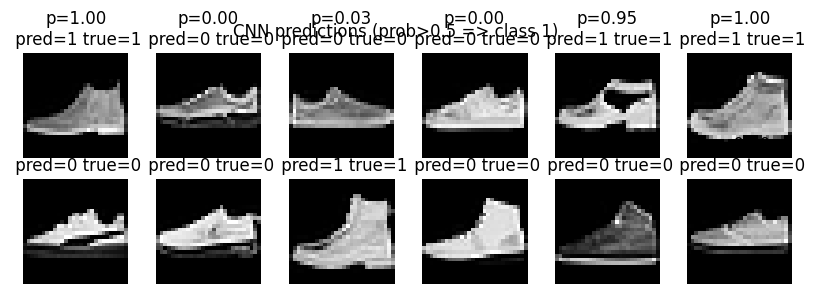

In [29]:
probs = model.predict(x_test_bin[:12], verbose=0).squeeze()
preds = (probs > 0.5).astype(int)

plt.figure(figsize=(10,3))
for i in range(12):
    plt.subplot(2,6,i+1)
    plt.imshow(x_test_bin[i].squeeze(), cmap="gray")
    plt.title(f"p={probs[i]:.2f}\n pred={preds[i]} true={int(y_test_bin[i])}")
    plt.axis("off")
plt.suptitle("CNN predictions (prob>0.5 => class 1)")
plt.show()

## 5) Transfer learning section (PDF)

The PDF explains transfer learning ideas (use pretrained models etc.).
But the code example here is actually a small CNN trained on CIFAR-10 (classes 0,1,2 only).
I’ll follow the PDF code exactly and make sure it runs.

In [34]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# Data (CIFAR-10)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Original shapes:")
print("x_train:", x_train.shape, "y_train:", y_train.shape)
print("x_test:", x_test.shape, "y_test:", y_test.shape)

# Keep classes 0,1,2 only
mask_train = (y_train < 3).flatten()
mask_test = (y_test < 3).flatten()

x_train = x_train[mask_train].astype("float32") / 255.0
y_train = y_train[mask_train].flatten()

x_test = x_test[mask_test].astype("float32") / 255.0
y_test = y_test[mask_test].flatten()

print("\nAfter filtering to classes 0,1,2:")
print("x_train:", x_train.shape, "y_train:", y_train.shape, "unique labels:", np.unique(y_train))
print("x_test:", x_test.shape, "y_test:", y_test.shape, "unique labels:", np.unique(y_test))

Original shapes:
x_train: (50000, 32, 32, 3) y_train: (50000, 1)
x_test: (10000, 32, 32, 3) y_test: (10000, 1)

After filtering to classes 0,1,2:
x_train: (15000, 32, 32, 3) y_train: (15000,) unique labels: [0 1 2]
x_test: (3000, 32, 32, 3) y_test: (3000,) unique labels: [0 1 2]


### Notes

- CIFAR-10 images are (32,32,3).
- Labels from `load_data()` come as shape (N,1), so PDF uses `.flatten()`.
- Normalizing `/255.0` makes pixel values 0..1 (better training).
- We keep only 3 classes to make it smaller / faster.

In [32]:
model = models.Sequential([
    layers.Input(shape=(32,32,3)),
    layers.Conv2D(32, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Conv2D(128, (3,3), activation="relu", padding="same"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3, activation="softmax")
])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224,579 (877.26 KB)

 Trainable params: 224,579 (877.26 KB)

 Non-trainable params: 0 (0.00 B)

### Notes (why softmax + sparse loss)

We have 3 classes (0,1,2), so:
- output layer is Dense(3, softmax)
- labels are integers (0/1/2), not one-hot
So loss = sparse_categorical_crossentropy

In [33]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

loss, acc = model.evaluate(x_test, y_test, verbose=0)
print("Test accuracy (tiny CNN):", acc)

Epoch 1/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.7258 - loss: 0.6591 - val_accuracy: 0.8167 - val_loss: 0.4565
Epoch 2/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8323 - loss: 0.4215 - val_accuracy: 0.8727 - val_loss: 0.3527
Epoch 3/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.8664 - loss: 0.3395 - val_accuracy: 0.8693 - val_loss: 0.3363
Epoch 4/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.8864 - loss: 0.2909 - val_accuracy: 0.8987 - val_loss: 0.2801
Epoch 5/5
211/211 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.9010 - loss: 0.2604 - val_accuracy: 0.8920 - val_loss: 0.2812
Test accuracy (tiny CNN): 0.8843333125114441


### Final notes (this whole course pattern)

The same 3 steps keep repeating in every example:

1) Create: define the layers (model architecture)
2) Compile: choose loss + optimizer + metrics
3) Fit: train the model with model.fit(...)

Then evaluate on test set to check generalization.